<a href="https://colab.research.google.com/github/HitenBangarwa/HitenMLlab/blob/main/NewLab1%262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

df = pd.read_csv(
    '/content/apartments_for_rent_classified_10K.csv',
    sep=';',
    encoding='latin1'   # 👈 FIX
)

df.head()



,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [7]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
for col in df.columns:
    print(col)



Dataset Shape: (10000, 22)

Column Names:
id
category
title
body
amenities
bathrooms
bedrooms
currency
fee
has_photo
pets_allowed
price
price_display
price_type
square_feet
address
cityname
state
latitude
longitude
source
time


In [8]:
df.info()

print("\nMissing Values:\n")
print(df.isnull().sum())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   5837 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [9]:
df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])



,id,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
count,1.000000e+04,9966.000000,9993.000000,10000.000000,10000.000000,9990.000000,9990.000000,1.000000e+04
mean,5.623396e+09,1.380544,1.744021,1486.277500,945.810500,37.695162,-94.652247,1.574891e+09
std,7.021025e+07,0.615410,0.942354,1076.507968,655.755736,5.495851,15.759805,3.762395e+06
min,5.508654e+09,1.000000,0.000000,200.000000,101.000000,21.315500,-158.022100,1.568744e+09
10%,5.509009e+09,1.000000,1.000000,750.000000,500.000000,30.305400,-121.512500,1.568767e+09
25%,5.509248e+09,1.000000,1.000000,949.000000,649.000000,33.679850,-101.301700,1.568781e+09
50%,5.668610e+09,1.000000,2.000000,1270.000000,802.000000,38.809800,-93.651600,1.577358e+09
75%,5.668626e+09,2.000000,2.000000,1695.000000,1100.000000,41.349800,-82.209975,1.577359e+09
90%,5.668635e+09,2.000000,3.000000,2395.000000,1500.000000,44.940500,-76.612600,1.577360e+09
max,5.668663e+09,8.500000,9.000000,52500.000000,40000.000000,61.594000,-70.191600,1.577362e+09


In [10]:
df_clean = df.drop(columns=[
    'id','category','title','body','amenities','currency',
    'fee','has_photo','pets_allowed','price_display',
    'price_type','address','cityname','state','source'
])

df_clean.head()



,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
0,NaN,0.0,790,101,38.9057,-76.9861,1577359415
1,NaN,1.0,425,106,37.9680,-87.6621,1577017063
2,1.0,0.0,1390,107,38.8910,-77.0816,1577359410
3,1.0,0.0,925,116,47.6160,-122.3275,1576667743
4,NaN,0.0,880,125,38.8738,-77.1055,1577359401


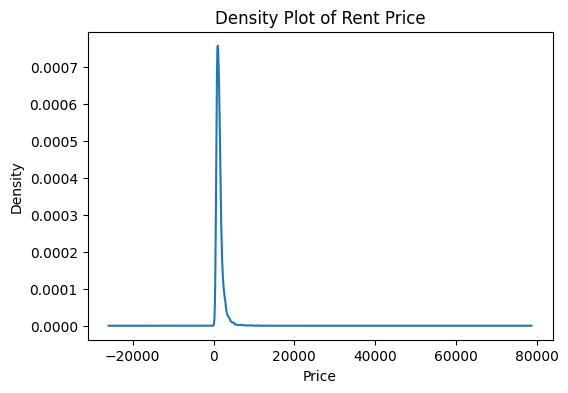

In [11]:
plt.figure(figsize=(6,4))
df_clean['price'].plot.density()
plt.title('Density Plot of Rent Price')
plt.xlabel('Price')
plt.show()



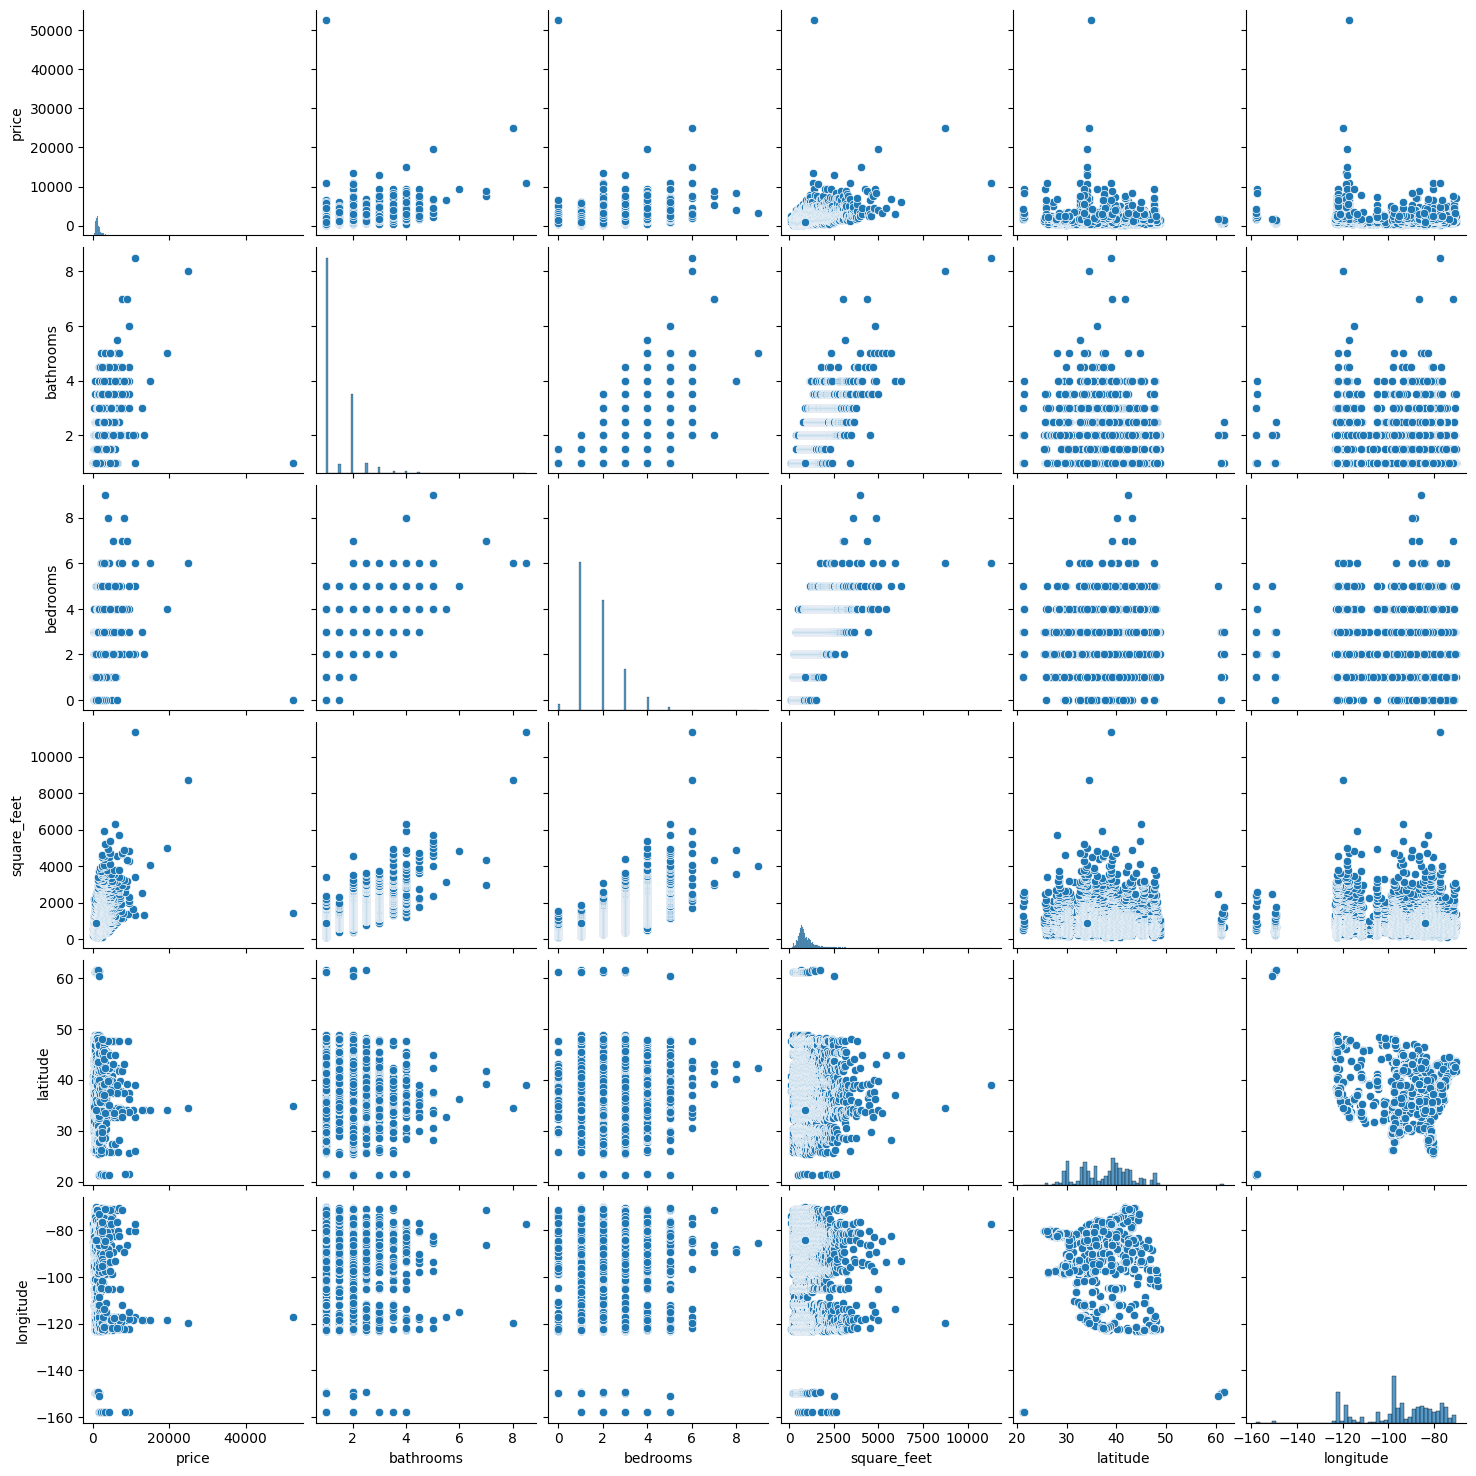

In [12]:
sample_cols = ['price', 'bathrooms', 'bedrooms', 'square_feet', 'latitude', 'longitude']
sns.pairplot(df_clean[sample_cols].dropna())



In [13]:
correlation_matrix = df_clean.corr()
correlation_matrix



,bathrooms,bedrooms,price,square_feet,latitude,longitude,time
bathrooms,1.000000,0.705856,0.411655,0.796557,-0.049920,-0.000592,-0.048461
bedrooms,0.705856,1.000000,0.306456,0.589194,0.024724,0.031177,0.032311
price,0.411655,0.306456,1.000000,0.390771,0.015075,-0.184250,-0.022298
square_feet,0.796557,0.589194,0.390771,1.000000,-0.010772,0.021984,0.006829
latitude,-0.049920,0.024724,0.015075,-0.010772,1.000000,-0.106327,-0.062938
longitude,-0.000592,0.031177,-0.184250,0.021984,-0.106327,1.000000,-0.188804
time,-0.048461,0.032311,-0.022298,0.006829,-0.062938,-0.188804,1.000000


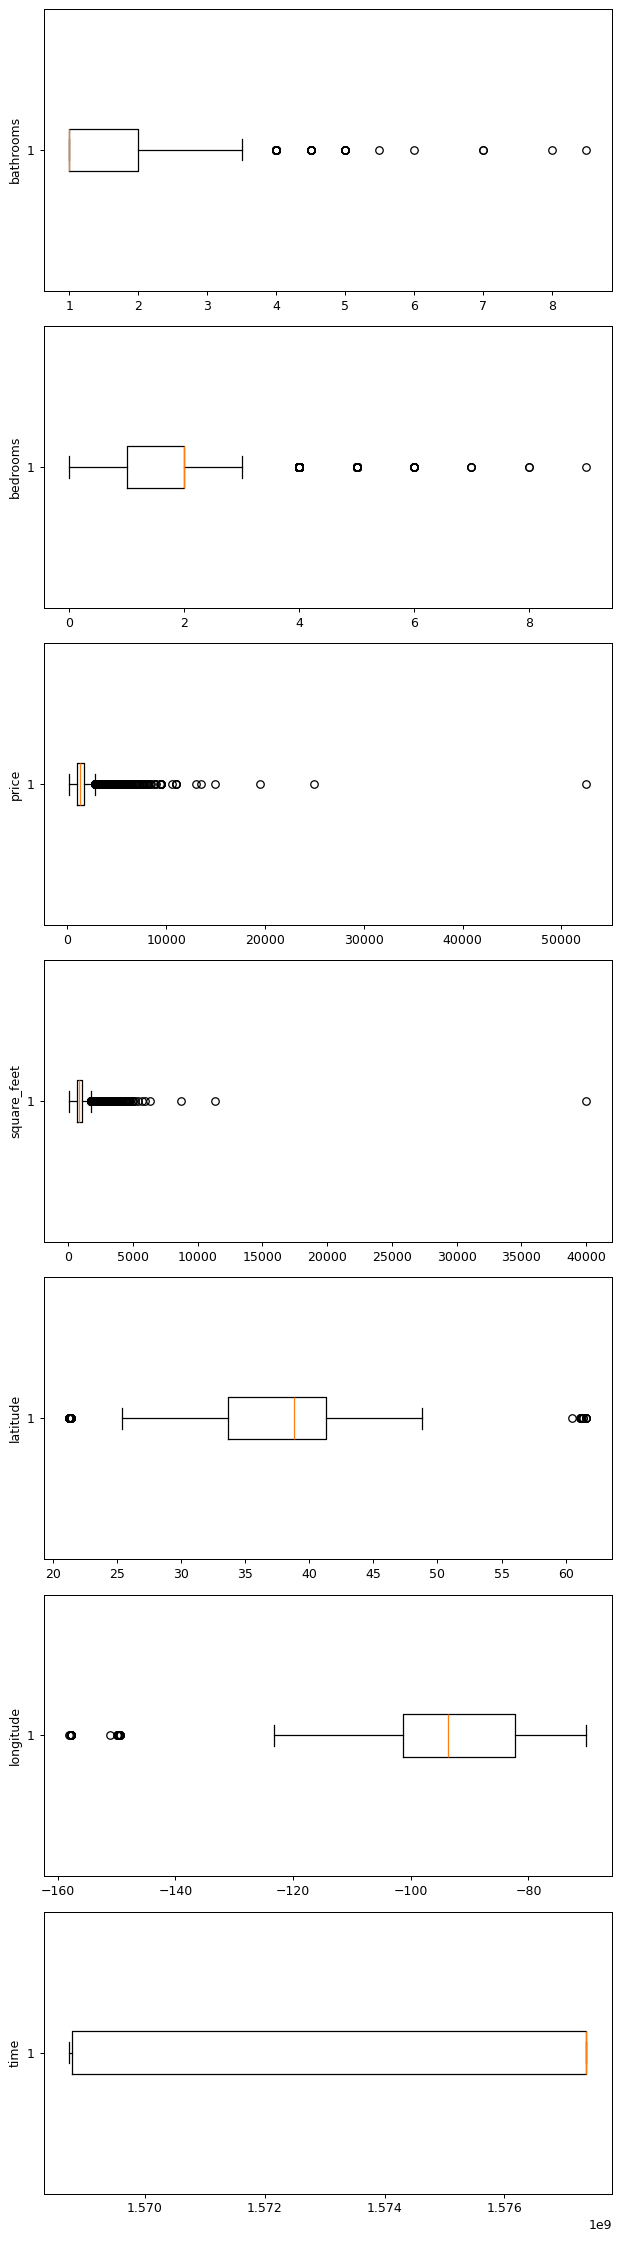

In [14]:
fig, axs = plt.subplots(len(df_clean.columns), 1, figsize=(7, 25), dpi=90)

for i, col in enumerate(df_clean.columns):
    axs[i].boxplot(df_clean[col].dropna(), vert=False)
    axs[i].set_ylabel(col)

plt.tight_layout()
plt.show()


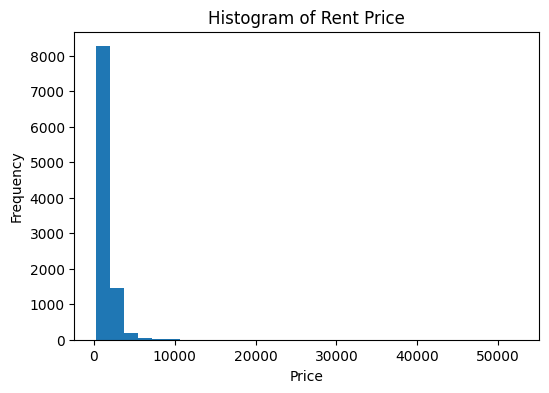

In [15]:
plt.figure(figsize=(6,4))
plt.hist(df_clean['price'].dropna(), bins=30)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Histogram of Rent Price')
plt.show()



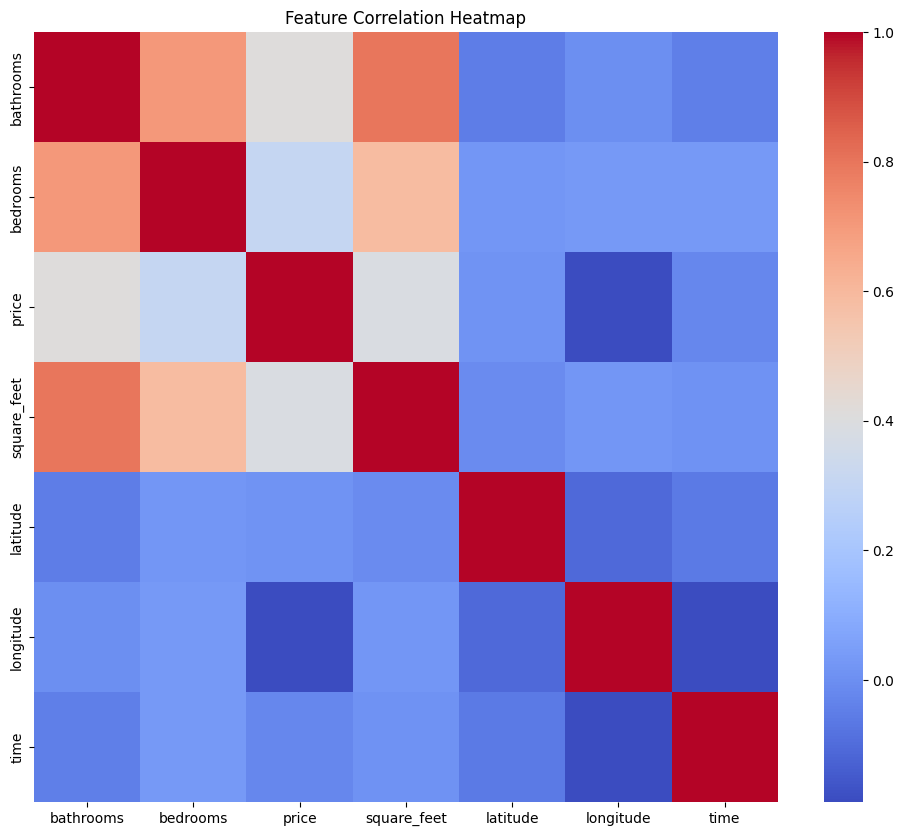

In [16]:
plt.figure(figsize=(12,10))
sns.heatmap(df_clean.corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()



In [17]:
X = df_clean.drop(columns=['price'])
y = df_clean['price']

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (10000, 6)
y shape: (10000,)


In [18]:
corr_target = df_clean.corr()['price'].sort_values(ascending=False)
corr_target



,price
price,1.000000
bathrooms,0.411655
square_feet,0.390771
bedrooms,0.306456
latitude,0.015075
time,-0.022298
longitude,-0.184250


In [19]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X.fillna(0))

X_minmax[:5]



array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 6.31647563e-01,
        5.12814347e-01, 9.99678472e-01],
       [0.00000000e+00, 1.11111111e-01, 1.25316424e-04, 6.16423678e-01,
        4.45254176e-01, 9.59954213e-01],
       [1.17647059e-01, 0.00000000e+00, 1.50379709e-04, 6.31408903e-01,
        5.12210001e-01, 9.99677891e-01],
       [1.17647059e-01, 0.00000000e+00, 3.75949272e-04, 7.73062311e-01,
        2.25883595e-01, 9.19421434e-01],
       [0.00000000e+00, 0.00000000e+00, 6.01518835e-04, 6.31129655e-01,
        5.12058756e-01, 9.99676847e-01]])

In [20]:
print("Variance:\n", df_clean.var())
print("\nStandard Deviation:\n", df_clean.std())


Variance:
 bathrooms      3.787293e-01
bedrooms       8.880309e-01
price          1.158869e+06
square_feet    4.300156e+05
latitude       3.020438e+01
longitude      2.483714e+02
time           1.415562e+13
dtype: float64

Standard Deviation:
 bathrooms      6.154099e-01
bedrooms       9.423539e-01
price          1.076508e+03
square_feet    6.557557e+02
latitude       5.495851e+00
longitude      1.575980e+01
time           3.762395e+06
dtype: float64


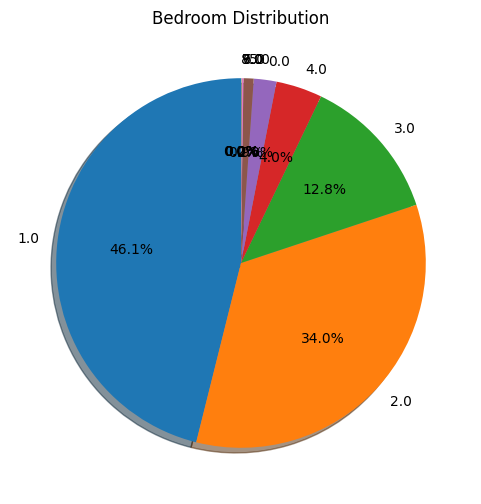

In [21]:
plt.figure(figsize=(6,6))

bedroom_counts = df['bedrooms'].value_counts()

plt.pie(
    bedroom_counts,
    labels=bedroom_counts.index,
    autopct='%.1f%%',
    shadow=True,
    startangle=90
)

plt.title('Bedroom Distribution')
plt.show()
